In [1]:
import sys
import os
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
# from src.models.horpca.horpca_torch import HoRPCA_Singleton#, MetricTracker
from src.synthetic_data.generate_lr_data import generate_low_rank_data
from src.synthetic_data.generate_anomaly import generate_spatio_temporal_anomaly
from src.gsp.graph import *
from src.gsp.gsp_vis import draw_graph_signal

## Synthetic Spatio-Temporal Anomaly Generation

In [16]:
G = nx.grid_2d_graph(7,7)
DG = nx.DiGraph(G)
DB = nx.incidence_matrix(DG, oriented=True).toarray()
B = nx.incidence_matrix(G, oriented=True).toarray()
dag, damg = generate_spatio_temporal_anomaly((49, 1, 1), DG, 1, time_m=3, local_m=1, duration=1, radius=2, seed=1,
                                              local_dist='gaussian')


ac, amc = generate_spatio_temporal_anomaly((49, 50, 50), G, 500, time_m=3, local_m=1, duration=1, radius=2, seed=1)
al, aml = generate_spatio_temporal_anomaly((49, 50, 50), G, 500, time_m=3, local_m=1, duration=1, radius=2, seed=1,
                                              local_dist='linear')
aq, amq = generate_spatio_temporal_anomaly((49, 50, 50), G, 500, time_m=3, local_m=1, duration=1, radius=2, seed=1,
                                              local_dist='quadratic')
ae, ame = generate_spatio_temporal_anomaly((49, 50, 50), G, 500, time_m=3, local_m=1, duration=1, radius=2, seed=1,
                                              local_dist='exponential')
ag, amg = generate_spatio_temporal_anomaly((49, 50, 50), G, 500, time_m=3, local_m=1, duration=1, radius=2, seed=1,
                                              local_dist='gaussian')
gc = B.T@((ac[:,0,4]).reshape(-1,1))
gl = B.T@((al[:,0,4]).reshape(-1,1))
# gq = B.T@((aq[:,0,4]).reshape(-1,1))
ge = B.T@((ae[:,0,4]).reshape(-1,1))
gg = B.T@((ag[:,0,4]).reshape(-1,1))
dge = DB.T@((ac[:,0,1]).reshape(-1,1))

[5.0, 2.3, 1.7578125, 1.7800000000000002, 2.914213562373095]
Window spreads in one dimension:
constant: 	2.0000
linear: 	0.9826
exponential: 	0.7416
gaussian: 	1.1716


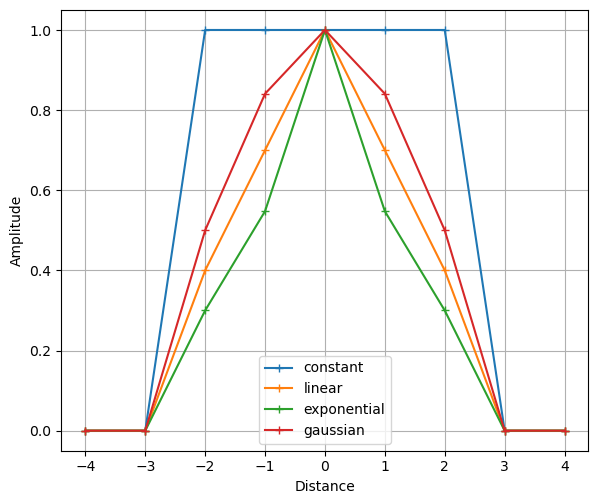

In [3]:
radius = 2
x = np.arange(4*radius+1) -2*radius
r_hop_mask = np.abs(x) <= radius
windows = [np.zeros(len(x)) for _ in range(5)]
window_names = ['constant','linear', 'quadratic', 'exponential', 'gaussian']
windows[0][r_hop_mask] = 1
windows[1][r_hop_mask] = 1 - np.abs(x[r_hop_mask])*0.6/radius
windows[2][r_hop_mask] = (1 - 0.5*np.abs(x[r_hop_mask])/(radius))**2
windows[3][r_hop_mask] = np.exp(-np.abs(x[r_hop_mask])*np.log(10/3)/radius)
windows[4][r_hop_mask] = np.exp(-np.log(2)*x[r_hop_mask]**2/(radius**2))
energies = [np.sum(w**2) for w in windows]
spread = [np.sum((w*x)**2)/energies[i] for i,w in enumerate(windows)]
fig, axe = plt.subplots(1,1, figsize=(6,5))
fig.tight_layout()
for i, w in enumerate(windows):
    if i != 2:
        axe.plot(x, w, label=window_names[i], marker='+')
axe.set_xlabel('Distance')
axe.set_ylabel('Amplitude')
axe.grid()
axe.legend();
print(energies)
print("Window spreads in one dimension:")
[print(f"{window_names[i]}: \t{spread[i]:.4f}") for i in range(5) if i != 2];
# lin = 1 - np.abs(x)*0.6/radius
# quad = (1 - np.abs(x)/6)**2
# expx = np.exp(-np.abs(x)*np.log(10/3)/radius)
# gauss = np.exp(-np.log(2)*x**2/(radius**2))
# plt.figure(figsize=(5,3))
# plt.plot(x, lin, label='linear')
# # plt.plot(x, quad, label='quadratic')
# plt.plot(x, expx, label='exp')
# plt.plot(x, gauss, label='gaussian')
# plt.ylim(0,1)
# plt.grid()
# plt.legend();

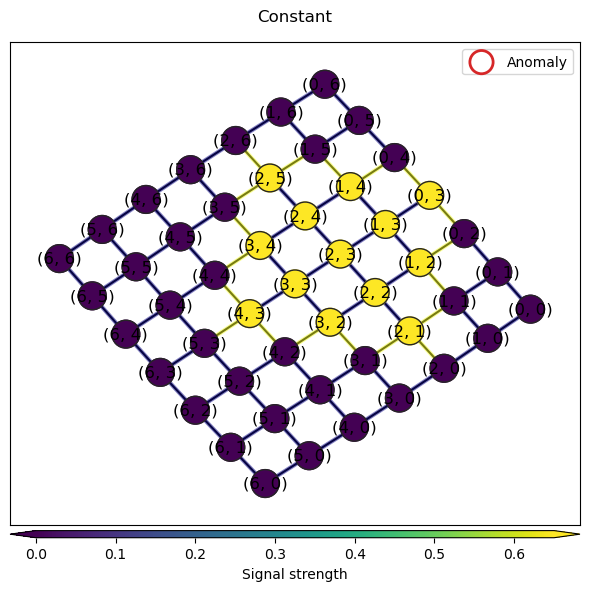

In [6]:
figsz = (6, 6)

draw_graph_signal(G, ac[:,0,4], suptitle='Constant', variation=np.abs(gc.ravel()), figsize=figsz);

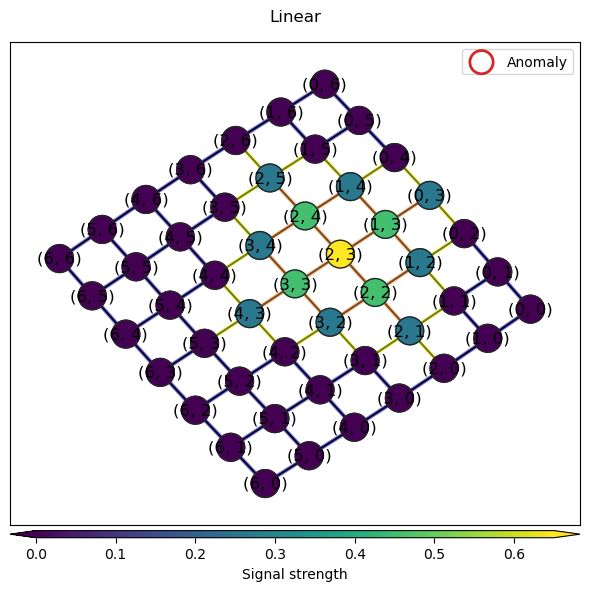

In [7]:
draw_graph_signal(G, al[:,0,4], suptitle='Linear', variation=np.abs(gl.ravel()), figsize=figsz);

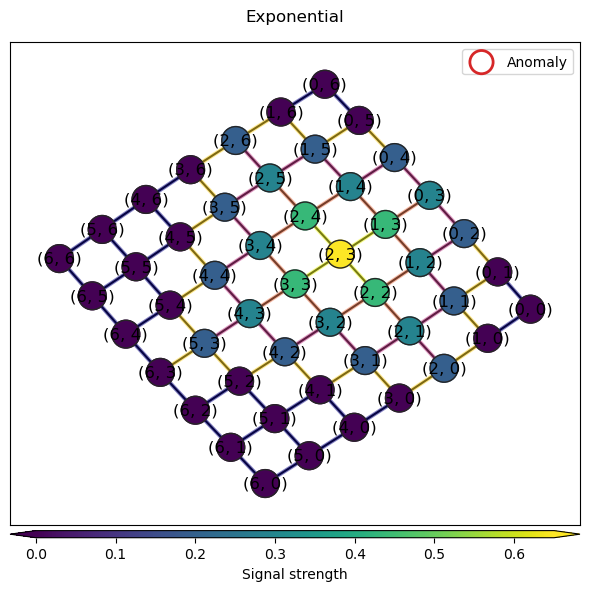

In [40]:
draw_graph_signal(G, ae[:,0,4], suptitle='Exponential', variation=np.abs(ge.ravel()), figsize=figsz);

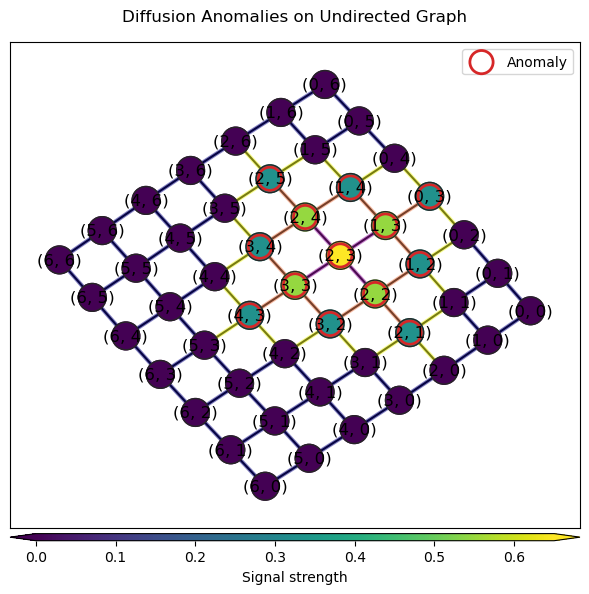

In [4]:
draw_graph_signal(G, ag[:,0,4], anomaly_labels=amg[:,0,4], suptitle='Diffusion Anomaly on Undirected Graph', variation=np.abs(gg.ravel()), figsize=(6,6));

In [ ]:
G_row = nx.grid_2d_graph(1,7)
DG_row = nx.DiGraph(G_row)
tril_indices = np.tril_indices(49, -1) 
Atry[tril_indices] = 0
Ga_row = nx.from_numpy_array(Atry, create_using=nx.DiGraph)
Ba_row = nx.incidence_matrix(Ga, oriented=True).toarray()

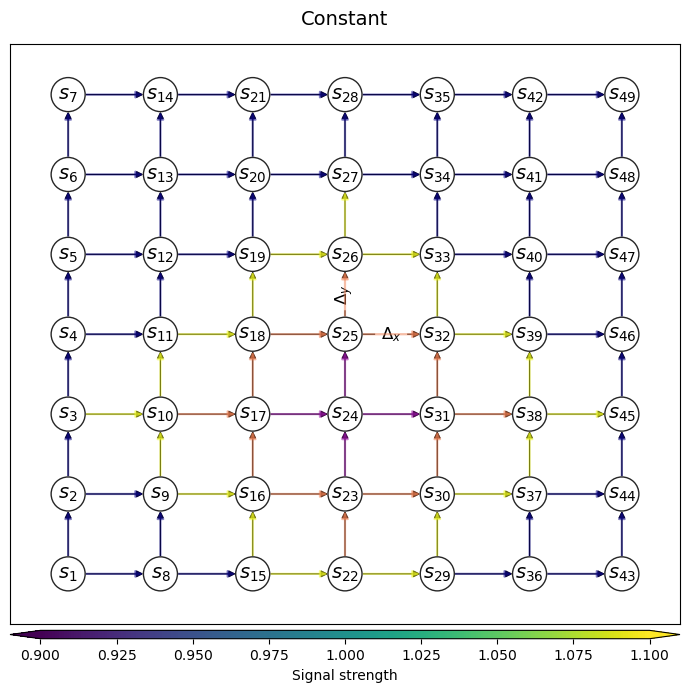

In [32]:
A = nx.adjacency_matrix(DG).toarray()
Atry = A.copy()
tril_indices = np.tril_indices(49, -1) 
Atry[tril_indices] = 0
Ga = nx.from_numpy_array(Atry, create_using=nx.DiGraph)
Ba = nx.incidence_matrix(Ga, oriented=True).toarray()
dga = Ba.T@((dag[:,0,0]).reshape(-1,1))
pos = [list(node) for node in G.nodes()]
pos = np.array(pos)
# print(pos.shape)
constant_1 = np.ones(49)
node_labels = {}
# node_labels = {24: r'$i,j$', 25: r'$._{i+1,j}$',31: r'$i,j+1$'}
node_labels={i-1: r'$s_{' + str(i) + '}$' for i in range(1,50)}
edge_labels = {(24,25): r'$\Delta_y$', (24,31): r'$\Delta_x$'}
edge_font_size = 12
node_font_size = 14
draw_graph_signal(Ga, constant_1, pos=pos, edge_width=0.8, edge_labels=edge_labels, edge_font_size=edge_font_size,
                    cmap='Grays', legend_on=False, node_size=600, node_font_size=node_font_size, node_labels=node_labels,
                   suptitle='Constant', variation=np.abs(dga.ravel()), figsize=(7,7));

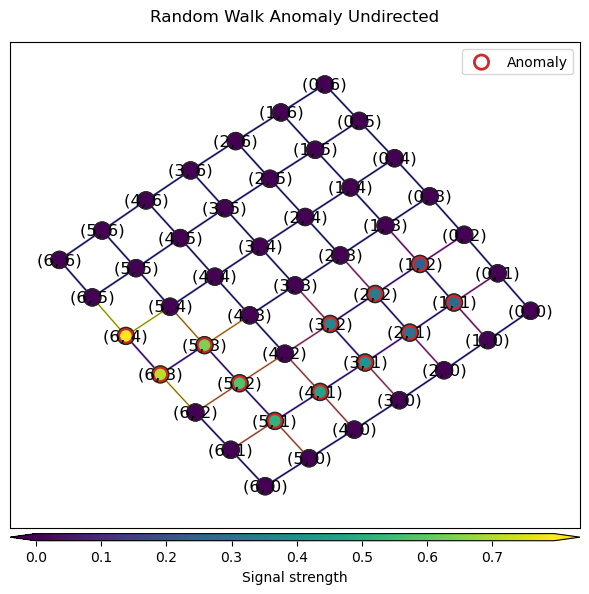

In [19]:
an, anm = generate_spatio_temporal_anomaly((49,1,1), G, 1, time_m=3, local_m=1,
                             duration=1, radius=11, seed=7, 
                             local_dist='exponential', anomaly_spread='anisotropic')
an_g = B.T@((an[:,0,0]).reshape(-1,1))
draw_graph_signal(G, an[:,0,0], anomaly_labels=anm[:,0,0],node_size=150, layout='spring', edge_width=08,suptitle='Random Walk Anomaly Undirected', variation=np.abs(an_g.ravel()), figsize=(6,6));

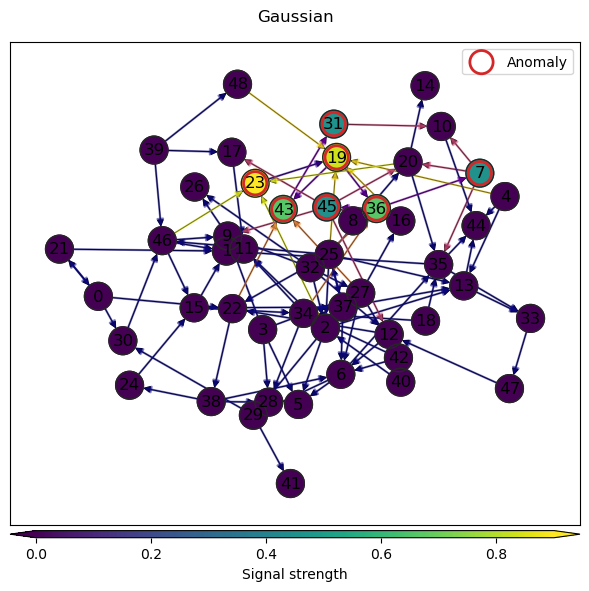

In [5]:
G_er = nx.erdos_renyi_graph(49, 0.04, directed=True, seed=2)
B_er = nx.incidence_matrix(G_er, oriented=True).toarray()
a_er_e, am_er_e = generate_spatio_temporal_anomaly((49, 1,1), G_er, 1, time_m=3, local_m=1, duration=1, 
                                                   radius=3, seed=1, local_dist='gaussian')
draw_graph_signal(G_er, a_er_e[:,0,0], anomaly_labels=am_er_e[:,0,0], suptitle='Gaussian', figsize=(6,6),
                edge_width=0.8, variation=np.abs(B_er.T@a_er_e[:,0,0].ravel()), layout='spring');

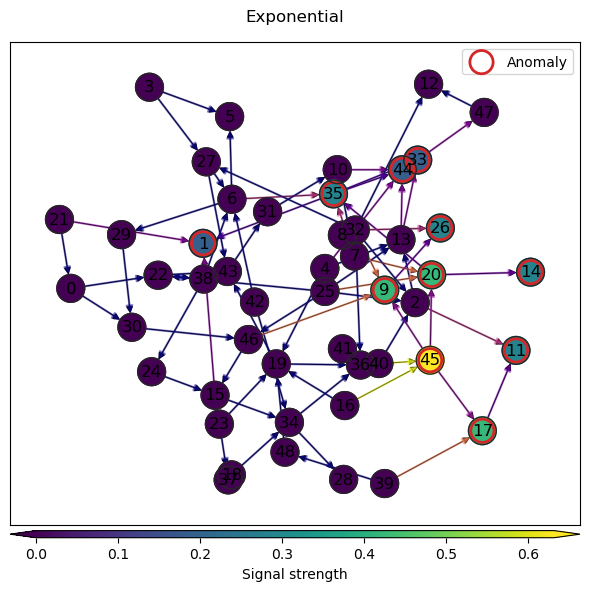

In [6]:
G_er = nx.erdos_renyi_graph(49, 0.03, directed=True, seed=2)
B_er = nx.incidence_matrix(G_er, oriented=True).toarray()
a_er_e, am_er_e = generate_spatio_temporal_anomaly((49, 1,1), G_er, 1, time_m=3, local_m=1, duration=1, 
                                                   radius=3, seed=15, local_dist='exponential')
draw_graph_signal(G_er, a_er_e[:,0,0], anomaly_labels=am_er_e[:,0,0], suptitle='Exponential', figsize=(6,6),
                edge_width=0.8, variation=np.abs(B_er.T@a_er_e[:,0,0].ravel()));

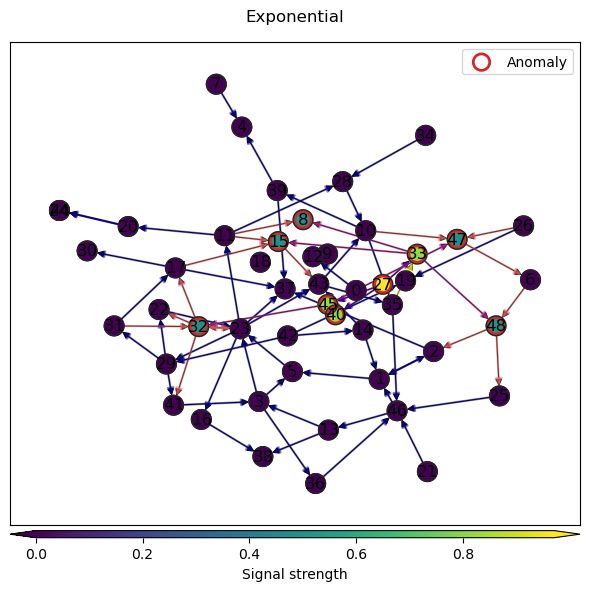

In [40]:
Gnm = nx.gnm_random_graph(49, 75, seed=2, directed=True)
B_nm = nx.incidence_matrix(Gnm, oriented=True).toarray()
a_nm_e, am_nm_e = generate_spatio_temporal_anomaly((49, 1,1), Gnm, 1, time_m=3, local_m=1, duration=1, 
                                                   radius=2, seed=76, local_dist='gaussian', distribution='uniform')
draw_graph_signal(Gnm, a_nm_e[:,0,0], anomaly_labels=am_nm_e[:,0,0], suptitle='Exponential', figsize=(6,6),
                edge_width=0.8, variation=np.abs(B_nm.T@a_nm_e[:,0,0].ravel()) ,node_size=200, layout='spring');

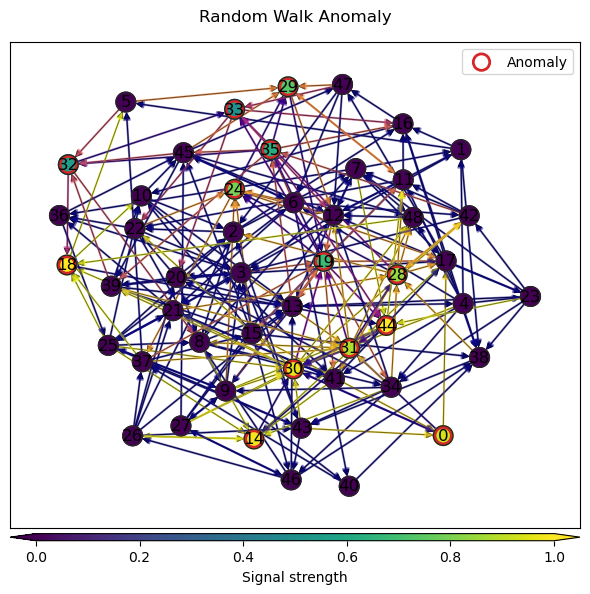

In [35]:
Gnm = nx.gnm_random_graph(49, 220, seed=31, directed=True)
B_nm = nx.incidence_matrix(Gnm, oriented=True).toarray()
a_nm_e, am_nm_e = generate_spatio_temporal_anomaly((49, 1,1), Gnm, 1, time_m=3, local_m=1, duration=1, 
                                    radius=12, seed=321, local_dist='gaussian',
                                     distribution='constant', anomaly_spread='anisotropic')
draw_graph_signal(Gnm, a_nm_e[:,0,0], anomaly_labels=am_nm_e[:,0,0], suptitle='Random Walk Anomaly', figsize=(6,6),
                edge_width=0.8, variation=np.abs(B_nm.T@a_nm_e[:,0,0].ravel()) ,node_size=200, layout='spring');